In [34]:
import numpy as np
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully!")

Libraries imported successfully!


In [40]:
import os

file_path = '/content/Restaurant_Reviews.tsv'
if os.path.exists(file_path):
    print(f"The file '{file_path}' exists.")
else:
    print(f"The file '{file_path}' does not exist. Please ensure it is uploaded to the '/content/' directory.")

The file '/content/Restaurant_Reviews.tsv' does not exist. Please ensure it is uploaded to the '/content/' directory.


In [78]:
# Remove rows where 'Liked' column has NaN values
df.dropna(subset=['Liked'], inplace=True)

print("DataFrame after dropping rows with NaN in 'Liked' column:")
display(df.head())

# Convert 'Liked' column to integer type, as it should contain 0 or 1
df['Liked'] = df['Liked'].astype(int)

print("\nUpdated Sentiment Distribution after cleaning:")
print(df['Liked'].value_counts())

DataFrame after dropping rows with NaN in 'Liked' column:


,Review,Liked
2,1 Crust is not...,0.0
3,2 Not tasty and the texture was just ...,0.0
4,3 Stopped by during the late May bank holiday...,1.0
5,4 The selection on the menu was great and so ...,1.0



Updated Sentiment Distribution after cleaning:
Liked
0    2
1    2
Name: count, dtype: int64


In [49]:
nltk.download("stopwords")

print("Stopwords downloaded successfully!")

Stopwords downloaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [69]:
import pandas as pd


df = pd.read_csv('/Restaurant_Reviews.tsv', sep=r'\t|(?<=\D)\s+(?=[01]$)', engine='python', header=None, skiprows=1, names=['Review', 'Liked'])


print("Columns present:", df.columns.tolist())
display(df.head())

print("\nLiked Counts:")
print(df['Liked'].value_counts())

Columns present: ['Review', 'Liked']


,Review,Liked
0,Wow... Loved this place.,NaN
1,1,NaN
2,1 Crust is not...,0.0
3,2 Not tasty and the texture was just ...,0.0
4,3 Stopped by during the late May bank holiday...,1.0



Liked Counts:
Liked
0.0    2
1.0    2
Name: count, dtype: int64


In [70]:
corpus = []
ps = PorterStemmer()
english_stopwords = set(stopwords.words("english"))

for i in range(len(df)):
    review = re.sub("[^a-zA-Z]", " ", df["Review"].iloc[i]).lower()
    words = review.split()
    words = [w for w in words if w not in english_stopwords]
    words = [ps.stem(w) for w in words]
    corpus.append(" ".join(words))

print("Preprocessing completed!")
print("\nFirst 10 processed reviews:")
print(corpus[:10])

Preprocessing completed!

First 10 processed reviews:
['wow love place', '', 'crust good', 'tasti textur nasti', 'stop late may bank holiday', 'select menu great wer']


In [105]:
cv = CountVectorizer(max_features=1500)
X = cv.fit_transform(corpus).toarray()
y = df.iloc[:, 1].values
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (4, 14)
Target shape: (4,)


In [106]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.20, random_state=0
)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (3, 14)
Testing data shape: (1, 14)


In [107]:
model = RandomForestClassifier(
n_estimators=35,
random_state=42
)
model.fit(X_train, y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [108]:
model_score = model.score(X_test, y_test)
print("Model Accuracy:", round(model_score * 100, 2), "%")
y_pred = model.predict(X_test)
print("Predictions completed!")

Model Accuracy: 0.0 %
Predictions completed!


In [102]:
score1 = accuracy_score(y_test, y_pred)
score2 = precision_score(y_test, y_pred, zero_division=0)
score3 = recall_score(y_test, y_pred, zero_division=0)
print("---- Scores ----")
print("Accuracy:", round(score1 * 100, 2), "%")
print("Precision:", round(score2, 2))
print("Recall:", round(score3, 2))

---- Scores ----
Accuracy: 0.0 %
Precision: 0.0
Recall: 0.0


In [103]:
print("Classification Report:")
print(classification_report(
y_test,
y_pred,
zero_division=0
))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00       0.0
         1.0       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0



Confusion Matrix:
[[0 0]
 [1 0]]


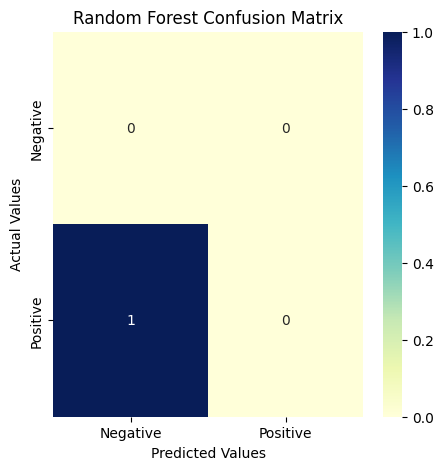

In [104]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
plt.figure(figsize=(5, 5))
sns.heatmap(
cm,
annot=True,
fmt="d",
cmap="YlGnBu",
xticklabels=["Negative", "Positive"],
yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [110]:
best_accuracy = 0
n_estimators_val = 5

print("Testing different n_estimators values...\n")

for i in range(1, 30, 2):
    temp_model = RandomForestClassifier(n_estimators=i, random_state=42)
    temp_model.fit(X_train, y_train)
    temp_pred = temp_model.predict(X_test)
    score = accuracy_score(y_test, temp_pred)

    print("n_estimators =", i, "Accuracy =", round(score * 100, 2), "%")

    if score > best_accuracy:
        best_accuracy = score
        n_estimators_val = i

print("\nBest accuracy:", round(best_accuracy * 100, 2), "% with n_estimators =", n_estimators_val)

Testing different n_estimators values...

n_estimators = 1 Accuracy = 0.0 %
n_estimators = 3 Accuracy = 0.0 %
n_estimators = 5 Accuracy = 0.0 %
n_estimators = 7 Accuracy = 0.0 %
n_estimators = 9 Accuracy = 0.0 %
n_estimators = 11 Accuracy = 0.0 %
n_estimators = 13 Accuracy = 0.0 %
n_estimators = 15 Accuracy = 0.0 %
n_estimators = 17 Accuracy = 0.0 %
n_estimators = 19 Accuracy = 0.0 %
n_estimators = 21 Accuracy = 0.0 %
n_estimators = 23 Accuracy = 0.0 %
n_estimators = 25 Accuracy = 0.0 %
n_estimators = 27 Accuracy = 0.0 %
n_estimators = 29 Accuracy = 0.0 %

Best accuracy: 0 % with n_estimators = 5


In [111]:
model = RandomForestClassifier(
n_estimators=n_estimators_val,
random_state=42
)
model.fit(X_train, y_train)
print("Optimized Random Forest Model:")
print(model)

Optimized Random Forest Model:
RandomForestClassifier(n_estimators=5, random_state=42)


In [114]:
def predict_sentiment(sample_review):
    review = re.sub("[^a-zA-Z]", " ", sample_review).lower()
    words = review.split()
    words = [w for w in words if w not in english_stopwords]
    words = [ps.stem(w) for w in words]
    review = " ".join(words)
    data = cv.transform([review]).toarray()
    return model.predict(data)[0]

sample_review = "The food is really good here."
prediction = predict_sentiment(sample_review)

print("Review:", sample_review)
if prediction == 1:
    print("This is a POSITIVE review.")
else:
    print("This is a NEGATIVE review!")

Review: The food is really good here.
This is a NEGATIVE review!


In [117]:
sample_review = "The food was absolutely awful."

prediction = predict_sentiment(sample_review)

print("Review:", sample_review)
if prediction == 1:
    print("This is a POSITIVE review.")
else:
    print("This is a NEGATIVE review!")

Review: The food was absolutely awful.
This is a NEGATIVE review!


In [118]:
final_predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, final_predictions)
precision = precision_score(y_test, final_predictions, zero_division=0)
recall = recall_score(y_test, final_predictions, zero_division=0)
print("\n==========================================")
print(" FINAL RANDOM FOREST MODEL PERFORMANCE")
print("==========================================")
print("Accuracy :", round(accuracy * 100, 2), "%")
print("Precision:", round(precision, 2))
print("Recall   :", round(recall, 2))
print("Best n_estimators:", n_estimators_val)


 FINAL RANDOM FOREST MODEL PERFORMANCE
Accuracy : 0.0 %
Precision: 0.0
Recall   : 0.0
Best n_estimators: 5
